# Advanced Regression Ensemble for yprop_4_1 Dataset

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from tpot import TPOTRegressor


In [2]:
# Cell 2: Load Dataset
X = pd.read_parquet("data/yprop_4_1/1/X_train.parquet")
y = pd.read_parquet("data/yprop_4_1/1/y_train.parquet").values.ravel()


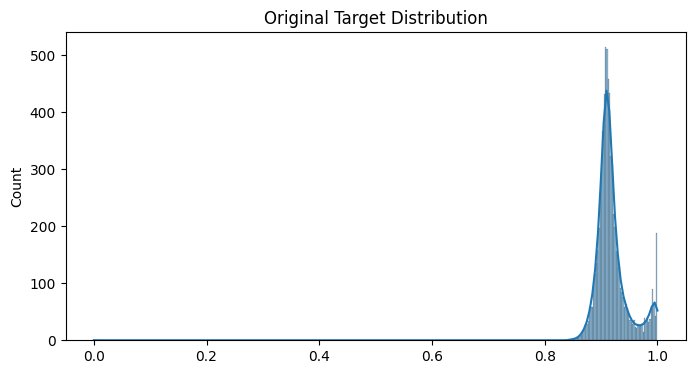

In [3]:
# Cell 3: Visualize Target
plt.figure(figsize=(8, 4))
sns.histplot(y, kde=True)
plt.title("Original Target Distribution")
plt.show()

y_log = np.log1p(y)


In [4]:
# Cell 4: Preprocessing
X = X.fillna(X.median(numeric_only=True))
X = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
# Cell 5: TPOT Feature Engineering
os.environ["TPOT_USE_DASK"] = "False"

tpot = TPOTRegressor(
    generations=2,
    population_size=10,
    random_state=42,
    n_jobs=1,
    max_time_mins=3
)
tpot.fit(X_scaled, y_log)
pipeline = tpot.fitted_pipeline_
X_tpot = pipeline[:-1].transform(X_scaled) if hasattr(pipeline, "transform") else X_scaled


/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 53966 instead
  warnings.warn(
Generation:  50%|███████████████████████████████▌                               | 1/2 [06:10<06:10, 370.57s/it]


In [17]:
# Cell 6: Train-test Split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)


In [18]:
# Cell 7: Model Training and R2 Evaluation

# Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_val)
gb_r2 = r2_score(y_val, gb_pred)

# LightGBM
lgb_model = LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_val)
lgb_r2 = r2_score(y_val, lgb_pred)

# CatBoost
cat_model = CatBoostRegressor(random_state=42, verbose=0)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_val)
cat_r2 = r2_score(y_val, cat_pred)

# HistGradientBoosting
hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_train, y_train)
hgb_pred = hgb_model.predict(X_val)
hgb_r2 = r2_score(y_val, hgb_pred)

# ExtraTrees
et_model = ExtraTreesRegressor(random_state=42, n_jobs=-1)
et_model.fit(X_train, y_train)
et_pred = et_model.predict(X_val)
et_r2 = r2_score(y_val, et_pred)

# XGBoost
xgb_model = XGBRegressor(random_state=42, n_jobs=1)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_val)
xgb_r2 = r2_score(y_val, xgb_pred)


/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [19]:
# Updated Weighted Ensemble including XGBoost
weights = np.array([gb_r2, lgb_r2, cat_r2, xgb_r2])
weights = weights / weights.sum()

weighted_pred = (gb_pred * weights[0] +
                 lgb_pred * weights[1] +
                 cat_pred * weights[2] +
                 xgb_pred * weights[3])
weighted_r2 = r2_score(y_val, weighted_pred)


In [20]:
# Updated Stacking Ensemble including XGBoost
estimators = [
    ('gb', gb),
    ('lgb', lgb_model),
    ('cat', cat_model),
    ('hgb', hgb_model),
    ('et', et_model),
    ('xgb', xgb_model)
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)
stacking_model.fit(X_train, y_train)
stacking_pred = stacking_model.predict(X_val)
stacking_r2 = r2_score(y_val, stacking_pred)


/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not h

In [21]:
# Cell 10: Compare R2 Scores
print("Model Comparison (R² scores):")
print(f"Gradient Boosting R2: {gb_r2:.4f}")
print(f"LightGBM R2: {lgb_r2:.4f}")
print(f"CatBoost R2: {cat_r2:.4f}")
print(f"XGBoost R2: {xgb_r2:.4f}")
print(f"HistGradientBoosting R2: {hgb_r2:.4f}")
print(f"ExtraTrees R2: {et_r2:.4f}")
print(f"Weighted Ensemble R2: {weighted_r2:.4f}")
print(f"Stacking Ensemble R2: {stacking_r2:.4f}")


Model Comparison (R² scores):
Gradient Boosting R2: 0.0240
LightGBM R2: 0.0217
CatBoost R2: 0.0232
XGBoost R2: -0.0064
HistGradientBoosting R2: 0.0284
ExtraTrees R2: 0.0128
Weighted Ensemble R2: 0.0285
Stacking Ensemble R2: 0.0276


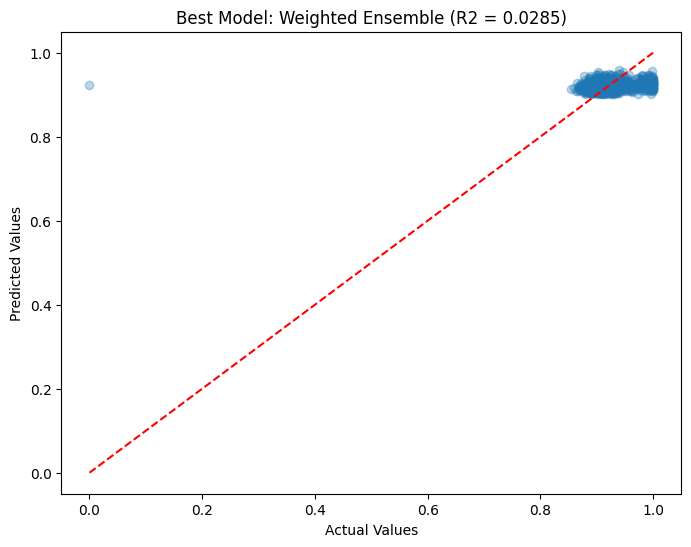

In [12]:
# Cell 11: Plot Best Model Predictions
predictions = [gb_pred, lgb_pred, cat_pred, xgb_pred, weighted_pred, stacking_pred]
r2_scores = [gb_r2, lgb_r2, cat_r2, xgb_r2, weighted_r2, stacking_r2]
model_names = ['Gradient Boosting', 'LightGBM', 'CatBoost', 'XGBoost', 'Weighted Ensemble', 'Stacking Ensemble']
best_index = np.argmax(r2_scores)

plt.figure(figsize=(8, 6))
plt.scatter(np.expm1(y_val), np.expm1(predictions[best_index]), alpha=0.3)
plt.plot([min(np.expm1(y_val)), max(np.expm1(y_val))],
         [min(np.expm1(y_val)), max(np.expm1(y_val))], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Best Model: {model_names[best_index]} (R2 = {r2_scores[best_index]:.4f})")
plt.show()
